# MEI Generation for 3D Video Model (Mozaik Synthetic Data)

Generate Most Exciting Inputs (MEIs) for a model trained on Mozaik synthetic spike data
(`single_session_train_mozaik_no_beh.py`). The model was trained on 37,500 neurons with
144x256 upscaled screens and PoissonLoss on raw spike counts.

Two MEI types:
1. **Video MEI** — optimize a full spatio-temporal video clip `(1, 1, T, 144, 256)`
2. **Static MEI** — optimize a single frame `(1, 1, 144, 256)` repeated across time

Adapted from `mei_video_model.ipynb` (trained on original mouse data at 36x64).

In [1]:
import warnings
warnings.filterwarnings('ignore')
import sys
import types
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import HTML

# Mock datajoint and gitpython (only needed by nnfabrik's dj_helpers, not used here)
_dj = types.ModuleType('datajoint')
_dj.config = {}
for sub in ['utils', 'schema', 'schemas', 'fetch']:
    mod = types.ModuleType(f'datajoint.{sub}')
    setattr(_dj, sub, mod)
    sys.modules[f'datajoint.{sub}'] = mod
_dj.utils.to_camel_case = lambda s: s
_dj.schema.Schema = type('Schema', (), {})
_dj.schemas.Schema = type('Schema', (), {})
_dj.fetch.DataJointError = Exception
sys.modules['datajoint'] = _dj

_git = types.ModuleType('git')
_git.Repo = type('Repo', (), {})
_git.cmd = types.ModuleType('git.cmd')
sys.modules['git'] = _git
sys.modules['git.cmd'] = _git.cmd

BASE = '/mnt/vast-nhr/projects/nix00014/goirik/MOZAIK-new'
sys.path.insert(0, f'{BASE}/sensorium/notebooks/model_tutorial/nnfabrik_base')
sys.path.insert(0, f'{BASE}/experanto')
sys.path.insert(0, f'{BASE}/mei')
sys.path.insert(0, f'{BASE}/neuralpredictors')
sys.path.insert(0, f'{BASE}/latent_space_model')

from sensorium.models.make_model import make_video_model
from mei.optimization import MEI, optimize
from mei.stoppers import NumIterations
from mei.objectives import EvaluationObjective
from mei.tracking import Tracker
from mei.initial import RandomNormal
from mei.postprocessing import PNormConstraintAndClip

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


## Regularization callables

- **2D versions**: for static MEI `(B, C, H, W)`
- **Video versions**: for video MEI `(B, C, T, H, W)` — apply 2D ops per frame

In [2]:
# --- 2D versions (for static MEI, input shape (B, C, H, W)) ---

class FourierPrecondition:
    """Lowpass-filter gradient in Fourier space: G(fx,fy) = (fx^2+fy^2)^(-alpha)."""
    def __init__(self, alpha=0.1):
        self.alpha = alpha
        self._filter_cache = {}

    def _get_filter(self, H, W, device):
        key = (H, W, device)
        if key not in self._filter_cache:
            fy = torch.fft.fftfreq(H, device=device).unsqueeze(1)
            fx = torch.fft.fftfreq(W, device=device).unsqueeze(0)
            freq_sq = fx ** 2 + fy ** 2
            freq_sq[0, 0] = 1.0
            filt = freq_sq ** (-self.alpha)
            filt[0, 0] = 1.0
            self._filter_cache[key] = filt
        return self._filter_cache[key]

    def __call__(self, grad, i_iteration):
        H, W = grad.shape[-2:]
        filt = self._get_filter(H, W, grad.device)
        return torch.fft.ifft2(torch.fft.fft2(grad) * filt).real


def _make_gaussian_kernel_2d(sigma, dtype, device):
    """Build a 2D Gaussian kernel with size adapted to sigma (radius = ceil(3*sigma))."""
    radius = int(np.ceil(3.0 * sigma))
    kernel_size = 2 * radius + 1
    x = torch.arange(kernel_size, dtype=dtype, device=device) - radius
    kernel_1d = torch.exp(-0.5 * (x / max(sigma, 1e-6)) ** 2)
    kernel_1d = kernel_1d / kernel_1d.sum()
    kernel_2d = (kernel_1d[:, None] * kernel_1d[None, :]).unsqueeze(0).unsqueeze(0)
    return kernel_2d, radius


class DecayingGaussianBlur:
    """Gaussian blur with sigma decaying linearly over iterations."""
    def __init__(self, sigma_start=3.0, sigma_end=0.5, n_iter=500, preserve_norm=False):
        self.sigma_start = sigma_start
        self.sigma_end = sigma_end
        self.n_iter = n_iter
        self.preserve_norm = preserve_norm

    def __call__(self, mei, i_iteration):
        sigma = self.sigma_start + (self.sigma_end - self.sigma_start) * (i_iteration / max(self.n_iter - 1, 1))
        kernel_2d, padding = _make_gaussian_kernel_2d(sigma, mei.dtype, mei.device)
        if self.preserve_norm:
            norm_before = mei.norm()
        blurred = F.conv2d(mei, kernel_2d, padding=padding)
        if self.preserve_norm:
            norm_after = blurred.norm()
            if norm_after > 0:
                blurred = blurred * (norm_before / norm_after)
        return blurred


class RandomJitter:
    """Random spatial jitter for 2D input (B, C, H, W)."""
    def __init__(self, amount=2):
        self.amount = amount

    def __call__(self, mei, i_iteration):
        ox = torch.randint(-self.amount, self.amount + 1, (1,)).item()
        oy = torch.randint(-self.amount, self.amount + 1, (1,)).item()
        return torch.roll(mei, shifts=(ox, oy), dims=(2, 3))


# --- Video versions (for video MEI, input shape (B, C, T, H, W)) ---

class FourierPreconditionVideo:
    """Lowpass-filter gradient per frame in Fourier space."""
    def __init__(self, alpha=0.1):
        self.alpha = alpha
        self._filter_cache = {}

    def _get_filter(self, H, W, device):
        key = (H, W, device)
        if key not in self._filter_cache:
            fy = torch.fft.fftfreq(H, device=device).unsqueeze(1)
            fx = torch.fft.fftfreq(W, device=device).unsqueeze(0)
            freq_sq = fx ** 2 + fy ** 2
            freq_sq[0, 0] = 1.0
            filt = freq_sq ** (-self.alpha)
            filt[0, 0] = 1.0
            self._filter_cache[key] = filt
        return self._filter_cache[key]

    def __call__(self, grad, i_iteration):
        H, W = grad.shape[-2:]
        filt = self._get_filter(H, W, grad.device)
        return torch.fft.ifft2(torch.fft.fft2(grad) * filt).real


class DecayingGaussianBlurVideo:
    """Gaussian blur per frame for video tensor (B, C, T, H, W)."""
    def __init__(self, sigma_start=3.0, sigma_end=0.5, n_iter=500, preserve_norm=False):
        self.sigma_start = sigma_start
        self.sigma_end = sigma_end
        self.n_iter = n_iter
        self.preserve_norm = preserve_norm

    def __call__(self, mei, i_iteration):
        sigma = self.sigma_start + (self.sigma_end - self.sigma_start) * (i_iteration / max(self.n_iter - 1, 1))
        kernel_2d, padding = _make_gaussian_kernel_2d(sigma, mei.dtype, mei.device)
        B, C, T, H, W = mei.shape
        mei_flat = mei.reshape(B * C * T, 1, H, W)
        if self.preserve_norm:
            norm_before = mei_flat.norm()
        blurred = F.conv2d(mei_flat, kernel_2d, padding=padding)
        if self.preserve_norm:
            norm_after = blurred.norm()
            if norm_after > 0:
                blurred = blurred * (norm_before / norm_after)
        return blurred.reshape(B, C, T, H, W)


class RandomJitterVideo:
    """Random spatial jitter for video (B, C, T, H, W). Rolls spatial dims 3, 4."""
    def __init__(self, amount=2):
        self.amount = amount

    def __call__(self, mei, i_iteration):
        ox = torch.randint(-self.amount, self.amount + 1, (1,)).item()
        oy = torch.randint(-self.amount, self.amount + 1, (1,)).item()
        return torch.roll(mei, shifts=(ox, oy), dims=(3, 4))

## Pipeline validation with simulated complex cell

Before running MEI on the trained video model, verify the optimization pipeline
recovers the known preferred stimulus of a simulated complex cell (quadrature Gabor pair).
The ground truth is known — the MEI should look like a Gabor filter.

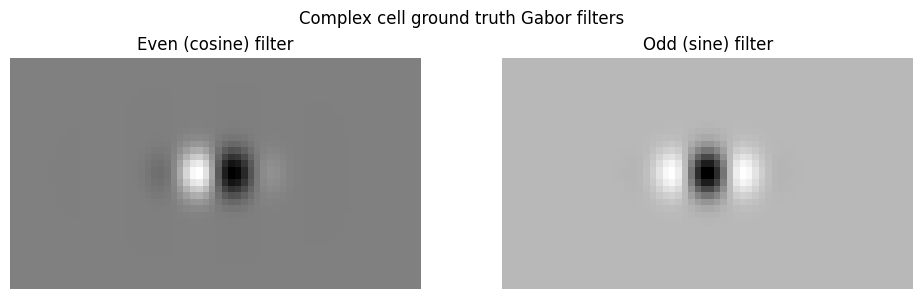

Complex cell output shape: torch.Size([1]), value: 1.8869


In [3]:
from laminr.simulated_models import complex_neuron_generator

# Create a complex cell at the center of the image, using same spatial res as video model
# img_res is [W, H] for meshgrid convention — np.meshgrid(linspace(W), linspace(H)) -> (H, W)
img_res = [64, 36]
loc = [0.0, 0.0]
complex_cell, grid = complex_neuron_generator(loc, img_res)
complex_cell = complex_cell.to(device).eval()

# Show the ground truth filters
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].imshow(complex_cell.even_filter.cpu().numpy(), cmap='gray')
axes[0].set_title('Even (cosine) filter')
axes[1].imshow(complex_cell.odd_filter.cpu().numpy(), cmap='gray')
axes[1].set_title('Odd (sine) filter')
for ax in axes:
    ax.axis('off')
plt.suptitle('Complex cell ground truth Gabor filters', fontsize=12)
plt.tight_layout()
plt.show()

# Verify forward pass works
with torch.no_grad():
    test = torch.randn(1, 1, 36, 64).to(device)
    out = complex_cell(test)
    print(f"Complex cell output shape: {out.shape}, value: {out.item():.4f}")

Vanilla MEI final activation: 2.8600


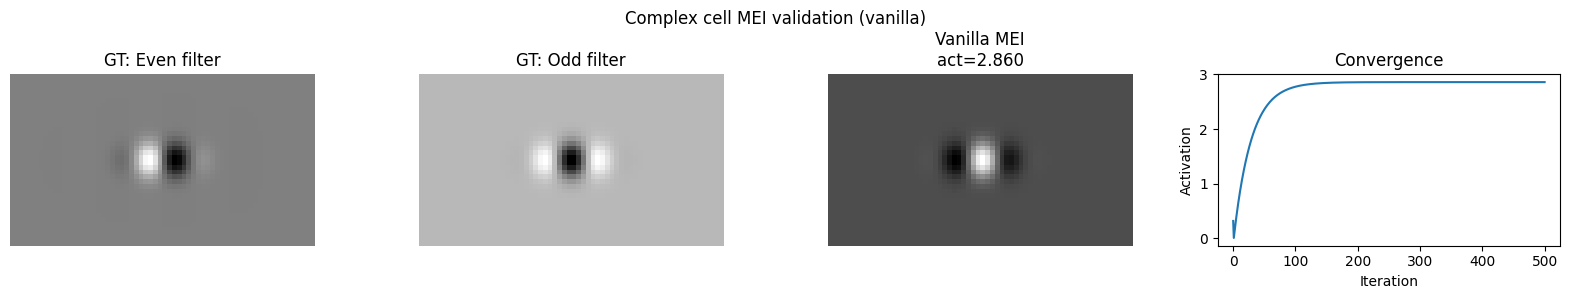

In [4]:
# Run MEI optimization on the complex cell — vanilla recipe
torch.manual_seed(42)

initial = RandomNormal()(1, 1, 36, 64).to(device)
optimizer = torch.optim.SGD([initial], lr=0.1)

mei_obj = MEI(
    func=complex_cell,
    initial=initial,
    optimizer=optimizer,
    transparency=False,
    inhibitory=False,
    postprocessing=PNormConstraintAndClip(
        norm_value=30.0, p=1,
        max_pixel_value=1.0, min_pixel_value=-1.0,
    ),
)

stopper = NumIterations(num_iterations=500)
tracker = Tracker(evaluation=EvaluationObjective(interval=1))
final_eval, mei_result = optimize(mei_obj, stopper, tracker)
cc_activations_vanilla = tracker.log['evaluation']['values']

print(f"Vanilla MEI final activation: {final_eval:.4f}")

# Visualize: ground truth vs MEI
fig, axes = plt.subplots(1, 4, figsize=(16, 3))
axes[0].imshow(complex_cell.even_filter.cpu().numpy(), cmap='gray')
axes[0].set_title('GT: Even filter')
axes[1].imshow(complex_cell.odd_filter.cpu().numpy(), cmap='gray')
axes[1].set_title('GT: Odd filter')
axes[2].imshow(mei_result.squeeze().detach().cpu().numpy(), cmap='gray')
axes[2].set_title(f'Vanilla MEI\nact={final_eval:.3f}')
axes[3].plot(cc_activations_vanilla)
axes[3].set_xlabel('Iteration')
axes[3].set_ylabel('Activation')
axes[3].set_title('Convergence')
for ax in axes[:3]:
    ax.axis('off')
plt.suptitle('Complex cell MEI validation (vanilla)', fontsize=12)
plt.tight_layout()
plt.show()

Paper MEI final activation: 1.0542


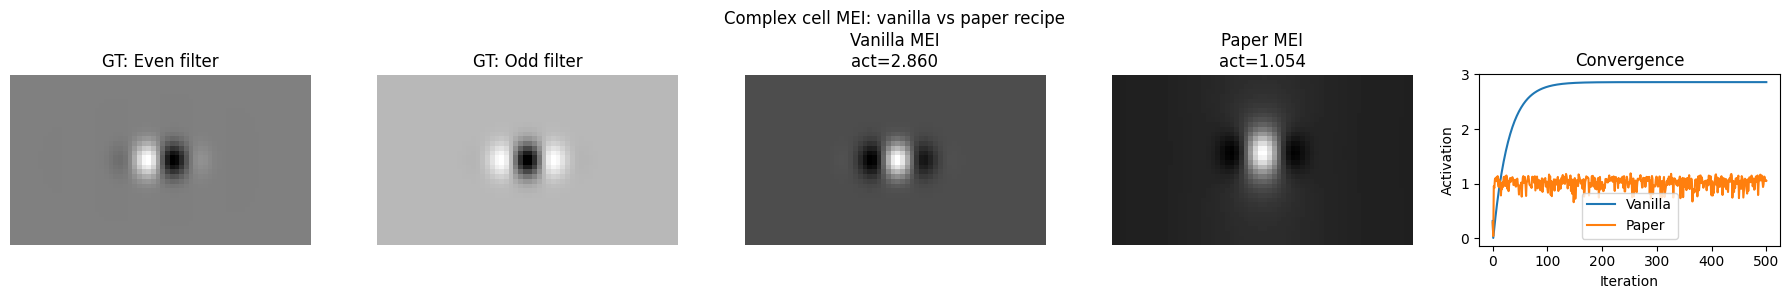

Pipeline validated -- same recipe used for both complex cell and real model.


In [5]:
# Run MEI optimization on the complex cell — paper recipe
# (Fourier precondition + jitter + PNormConstraintAndClip, no blur)
torch.manual_seed(42)

initial_paper = RandomNormal()(1, 1, 36, 64).to(device)
optimizer_paper = torch.optim.SGD([initial_paper], lr=0.1)

mei_paper = MEI(
    func=complex_cell,
    initial=initial_paper,
    optimizer=optimizer_paper,
    transparency=False,
    inhibitory=False,
    transform=RandomJitter(amount=2),
    precondition=FourierPrecondition(alpha=0.6),
    postprocessing=PNormConstraintAndClip(
        norm_value=30.0, p=1,
        max_pixel_value=1.0, min_pixel_value=-1.0,
    ),
)

stopper_paper = NumIterations(num_iterations=500)
tracker_paper = Tracker(evaluation=EvaluationObjective(interval=1))
final_eval_paper, mei_result_paper = optimize(mei_paper, stopper_paper, tracker_paper)
cc_activations_paper = tracker_paper.log['evaluation']['values']

print(f"Paper MEI final activation: {final_eval_paper:.4f}")

# Side-by-side: vanilla vs paper
fig, axes = plt.subplots(1, 5, figsize=(18, 3))
axes[0].imshow(complex_cell.even_filter.cpu().numpy(), cmap='gray')
axes[0].set_title('GT: Even filter')
axes[1].imshow(complex_cell.odd_filter.cpu().numpy(), cmap='gray')
axes[1].set_title('GT: Odd filter')
axes[2].imshow(mei_result.squeeze().detach().cpu().numpy(), cmap='gray')
axes[2].set_title(f'Vanilla MEI\nact={cc_activations_vanilla[-1]:.3f}')
axes[3].imshow(mei_result_paper.squeeze().detach().cpu().numpy(), cmap='gray')
axes[3].set_title(f'Paper MEI\nact={cc_activations_paper[-1]:.3f}')
axes[4].plot(cc_activations_vanilla, label='Vanilla')
axes[4].plot(cc_activations_paper, label='Paper')
axes[4].legend()
axes[4].set_xlabel('Iteration')
axes[4].set_ylabel('Activation')
axes[4].set_title('Convergence')
for ax in axes[:4]:
    ax.axis('off')
plt.suptitle('Complex cell MEI: vanilla vs paper recipe', fontsize=12)
plt.tight_layout()
plt.show()

print("Pipeline validated -- same recipe used for both complex cell and real model.")

---

# Load Mozaik-trained model from checkpoint

In [6]:
seed = 42
checkpoint_path = '../../test_training/single_session_mozaik_26872_no_beh/best.pth'

# --- Extract data_key and n_neurons from checkpoint ---
state_dict = torch.load(checkpoint_path, map_location='cpu')
readout_keys = [k for k in state_dict.keys() if k.startswith('readout.')]
data_key = readout_keys[0].split('.')[1]
bias_key = f'readout.{data_key}.bias'
n_neurons = state_dict[bias_key].shape[0]
print(f"Data key: {data_key}, Neurons: {n_neurons}")

# --- Model config (must match training script exactly) ---
factorised_3D_core_dict = dict(
    input_channels=1,
    hidden_channels=[32, 64, 128],
    spatial_input_kernel=(11, 11),
    temporal_input_kernel=11,
    spatial_hidden_kernel=(5, 5),
    temporal_hidden_kernel=5,
    stride=1,
    layers=3,
    gamma_input_spatial=10,
    gamma_input_temporal=0.01,
    bias=True,
    hidden_nonlinearities="elu",
    x_shift=0,
    y_shift=0,
    batch_norm=True,
    laplace_padding=None,
    input_regularizer="LaplaceL2norm",
    padding=False,
    final_nonlin=True,
    momentum=0.7,
)

readout_dict = dict(
    bias=True,
    init_mu_range=0.2,
    init_sigma=1.0,
    gamma_readout=0.0,
    gauss_type="full",
    grid_mean_predictor=None,
    share_features=False,
    share_grid=False,
    shared_match_ids=None,
    gamma_grid_dispersion=0.0,
    zig=False,
    out_channels=1,
    kernel_size=(11, 5),
    batch_size=4,
)

# --- Build model and load weights ---
n_neurons_dict = {data_key: n_neurons}
mean_activity_dict = {data_key: torch.zeros(n_neurons)}

model = make_video_model(
    None,
    seed,
    core_dict=factorised_3D_core_dict,
    core_type="3D_factorised",
    readout_dict=readout_dict.copy(),
    readout_type="gaussian",
    use_gru=False,
    gru_dict=None,
    use_shifter=False,
    shifter_dict=None,
    shifter_type=None,
    deeplake_ds=False,
    n_neurons_dict=n_neurons_dict,
    mean_activity_dict=mean_activity_dict,
    experanto=True,
    readout_dim=factorised_3D_core_dict["hidden_channels"][-1],
)

model.load_state_dict(state_dict)
model.to(device).eval()
for p in model.parameters():
    p.requires_grad_(False)

print(f"Model loaded successfully. Output neurons: {n_neurons}")
print(model)

Data key: 26872-17-20, Neurons: 37500
Model loaded successfully. Output neurons: 37500
VideoFiringRateEncoder(
  (core): Factorized3dCore(
    (_input_weight_regularizer): LaplaceL2norm(
      (laplace): Laplace()
    )
    (temporal_regularizer): DepthLaplaceL21d(
      (laplace): Laplace1d()
    )
    (features): Sequential(
      (layer0): Sequential(
        (conv_spatial): Conv3d(1, 32, kernel_size=(1, 11, 11), stride=(1, 1, 1))
        (conv_temporal): Conv3d(32, 32, kernel_size=(11, 1, 1), stride=(1, 1, 1))
        (norm): BatchNorm3d(32, eps=1e-05, momentum=0.7, affine=True, track_running_stats=True)
        (nonlin): ELU(alpha=1.0)
      )
      (layer1): Sequential(
        (conv_spatial_1): Conv3d(32, 64, kernel_size=(1, 5, 5), stride=(1, 1, 1))
        (conv_temporal_1): Conv3d(64, 64, kernel_size=(5, 1, 1), stride=(1, 1, 1))
        (norm): BatchNorm3d(64, eps=1e-05, momentum=0.7, affine=True, track_running_stats=True)
        (nonlin): ELU(alpha=1.0)
      )
      (layer2

## Determine temporal shrinkage

The 3D factorized core with `padding=False` reduces the temporal dimension.
Input resolution is 144x256 (upscaled from native 36x64 during training).

In [7]:
# Input resolution matches training: 144x256
IMG_H, IMG_W = 144, 256

with torch.no_grad():
    test_T = 50
    test_input = torch.randn(1, 1, test_T, IMG_H, IMG_W).to(device)
    test_output = model(test_input, data_key=data_key)
    T_out = test_output.shape[1]
    TEMPORAL_LOSS = test_T - T_out
    print(f"Input T={test_T} -> Output T'={T_out}, temporal loss={TEMPORAL_LOSS} frames")
    print(f"Output shape: {test_output.shape}")

VIDEO_T = 50
print(f"\nVideo MEI will optimize (1, 1, {VIDEO_T}, {IMG_H}, {IMG_W}) -> output T'={VIDEO_T - TEMPORAL_LOSS}")

Input T=50 -> Output T'=32, temporal loss=18 frames
Output shape: torch.Size([1, 32, 37500])

Video MEI will optimize (1, 1, 50, 144, 256) -> output T'=32


## MEI wrapper classes

The video model outputs `(batch, time, n_neurons)`. These wrappers select the target neuron
and average over time to produce a scalar for gradient ascent.

In [8]:
class VideoNeuronObjective(nn.Module):
    """Wraps video model for MEI: input (1,1,T,H,W) -> scalar activation."""
    def __init__(self, model, data_key, neuron_idx):
        super().__init__()
        self.model = model
        self.data_key = data_key
        self.neuron_idx = neuron_idx

    def forward(self, x):
        output = self.model(x, data_key=self.data_key)
        return output[:, :, self.neuron_idx].mean()


class StaticNeuronObjective(nn.Module):
    """Wraps video model for static MEI: input (1,1,H,W) -> repeat T times -> scalar."""
    def __init__(self, model, data_key, neuron_idx, n_frames):
        super().__init__()
        self.model = model
        self.data_key = data_key
        self.neuron_idx = neuron_idx
        self.n_frames = n_frames

    def forward(self, x):
        video = x.unsqueeze(2).expand(-1, -1, self.n_frames, -1, -1)
        output = self.model(video, data_key=self.data_key)
        return output[:, :, self.neuron_idx].mean()

## MEI generation functions

Norm values scaled for 144x256 resolution (4x spatial dimensions vs 36x64).

In [9]:
N_ITER = 500

# Scale norm_value proportional to sqrt(pixel count):
# original: 30.0 for 36*64=2304 pixels
# mozaik: 30.0 * sqrt(144*256 / 36*64) = 30.0 * 4 = 120.0
STATIC_NORM = 30.0 * np.sqrt((IMG_H * IMG_W) / (36 * 64))
print(f"Static norm value: {STATIC_NORM:.1f} (scaled from 30.0 for {IMG_H}x{IMG_W})")


def generate_video_mei(model, data_key, neuron_idx, n_iter=N_ITER, lr=0.1,
                       T=VIDEO_T, recipe='vanilla', seed=42):
    """Generate a video MEI optimizing (1, 1, T, IMG_H, IMG_W)."""
    torch.manual_seed(seed)

    func = VideoNeuronObjective(model, data_key, neuron_idx)
    func.eval()

    initial = RandomNormal()(1, 1, T, IMG_H, IMG_W).to(device)
    optimizer = torch.optim.SGD([initial], lr=lr)

    video_norm = STATIC_NORM * (T ** 0.5)

    if recipe == 'vanilla':
        mei_obj = MEI(
            func=func, initial=initial, optimizer=optimizer,
            transparency=False, inhibitory=False,
            postprocessing=PNormConstraintAndClip(
                norm_value=video_norm, p=1,
                max_pixel_value=1.0, min_pixel_value=-1.0,
            ),
        )
    elif recipe == 'paper':
        mei_obj = MEI(
            func=func, initial=initial, optimizer=optimizer,
            transparency=False, inhibitory=False,
            transform=RandomJitterVideo(amount=2),
            precondition=FourierPreconditionVideo(alpha=0.6),
            postprocessing=PNormConstraintAndClip(
                norm_value=video_norm, p=1,
                max_pixel_value=1.0, min_pixel_value=-1.0,
            ),
        )

    stopper = NumIterations(num_iterations=n_iter)
    tracker = Tracker(evaluation=EvaluationObjective(interval=1))
    final_eval, mei_result = optimize(mei_obj, stopper, tracker)
    activations = tracker.log['evaluation']['values']
    return mei_result, final_eval, activations


def generate_static_mei(model, data_key, neuron_idx, n_iter=N_ITER, lr=0.1,
                        T=VIDEO_T, recipe='vanilla', seed=42):
    """Generate a static MEI optimizing (1, 1, IMG_H, IMG_W), repeated T times for forward pass."""
    torch.manual_seed(seed)

    func = StaticNeuronObjective(model, data_key, neuron_idx, n_frames=T)
    func.eval()

    initial = RandomNormal()(1, 1, IMG_H, IMG_W).to(device)
    optimizer = torch.optim.SGD([initial], lr=lr)

    if recipe == 'vanilla':
        mei_obj = MEI(
            func=func, initial=initial, optimizer=optimizer,
            transparency=False, inhibitory=False,
            postprocessing=PNormConstraintAndClip(
                norm_value=STATIC_NORM, p=1,
                max_pixel_value=1.0, min_pixel_value=-1.0,
            ),
        )
    elif recipe == 'paper':
        mei_obj = MEI(
            func=func, initial=initial, optimizer=optimizer,
            transparency=False, inhibitory=False,
            transform=RandomJitter(amount=2),
            precondition=FourierPrecondition(alpha=0.6),
            postprocessing=PNormConstraintAndClip(
                norm_value=STATIC_NORM, p=1,
                max_pixel_value=1.0, min_pixel_value=-1.0,
            ),
        )

    stopper = NumIterations(num_iterations=n_iter)
    tracker = Tracker(evaluation=EvaluationObjective(interval=1))
    final_eval, mei_result = optimize(mei_obj, stopper, tracker)
    activations = tracker.log['evaluation']['values']
    return mei_result, final_eval, activations

Static norm value: 120.0 (scaled from 30.0 for 144x256)


## Run Static MEI generation

With 37,500 neurons we sample a subset. Each MEI forward pass is larger (144x256)
so expect ~16x more compute per iteration vs the 36x64 model.

In [10]:
import os
os.makedirs('../../figures/neuron_activation/neuron_activation_mozaik', exist_ok=True)

neuron_indices = np.linspace(0, n_neurons - 1, 100, dtype=int)
N_DEMO = len(neuron_indices)  # limit for demo; increase to len(neuron_indices) for full run
print(f"Generating static MEIs for {N_DEMO} of {len(neuron_indices)} sampled neurons")

static_meis = {}
static_activations = {}

for i, idx in enumerate(neuron_indices[:N_DEMO]):
    smei, seval, sacts = generate_static_mei(model, data_key, idx, recipe='paper')
    static_meis[idx] = smei.cpu()
    static_activations[idx] = sacts

    fig, ax = plt.subplots(figsize=(6, 3))
    ax.plot(sacts)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Predicted firing rate')
    ax.set_title(f'Neuron {idx} -- final activation: {sacts[-1]:.4f}')
    fig.tight_layout()
    fig.savefig(f'../../figures/neuron_activation/neuron_activation_mozaik/neuron_{idx}.png', dpi=150)
    plt.close(fig)

    print(f"  [{i+1}/{N_DEMO}] Neuron {idx}: static={seval:.4f}")

print("Done. Convergence curves saved to ../../figures/neuron_activation/neuron_activation_mozaik/")

Generating static MEIs for 100 of 100 sampled neurons
  [1/100] Neuron 0: static=0.0717
  [2/100] Neuron 378: static=0.0740
  [3/100] Neuron 757: static=0.0636
  [4/100] Neuron 1136: static=0.0890
  [5/100] Neuron 1515: static=0.1258
  [6/100] Neuron 1893: static=0.0533
  [7/100] Neuron 2272: static=0.1595
  [8/100] Neuron 2651: static=0.1850
  [9/100] Neuron 3030: static=0.0638
  [10/100] Neuron 3409: static=0.3558
  [11/100] Neuron 3787: static=0.3641
  [12/100] Neuron 4166: static=0.0819
  [13/100] Neuron 4545: static=0.0836
  [14/100] Neuron 4924: static=0.1643
  [15/100] Neuron 5302: static=0.0503
  [16/100] Neuron 5681: static=0.0774
  [17/100] Neuron 6060: static=0.0815
  [18/100] Neuron 6439: static=0.2147
  [19/100] Neuron 6818: static=0.1289
  [20/100] Neuron 7196: static=0.0714
  [21/100] Neuron 7575: static=0.0313
  [22/100] Neuron 7954: static=0.0830
  [23/100] Neuron 8333: static=0.0320
  [24/100] Neuron 8711: static=0.1287
  [25/100] Neuron 9090: static=0.1047
  [26/100]

## Visualize Static MEIs

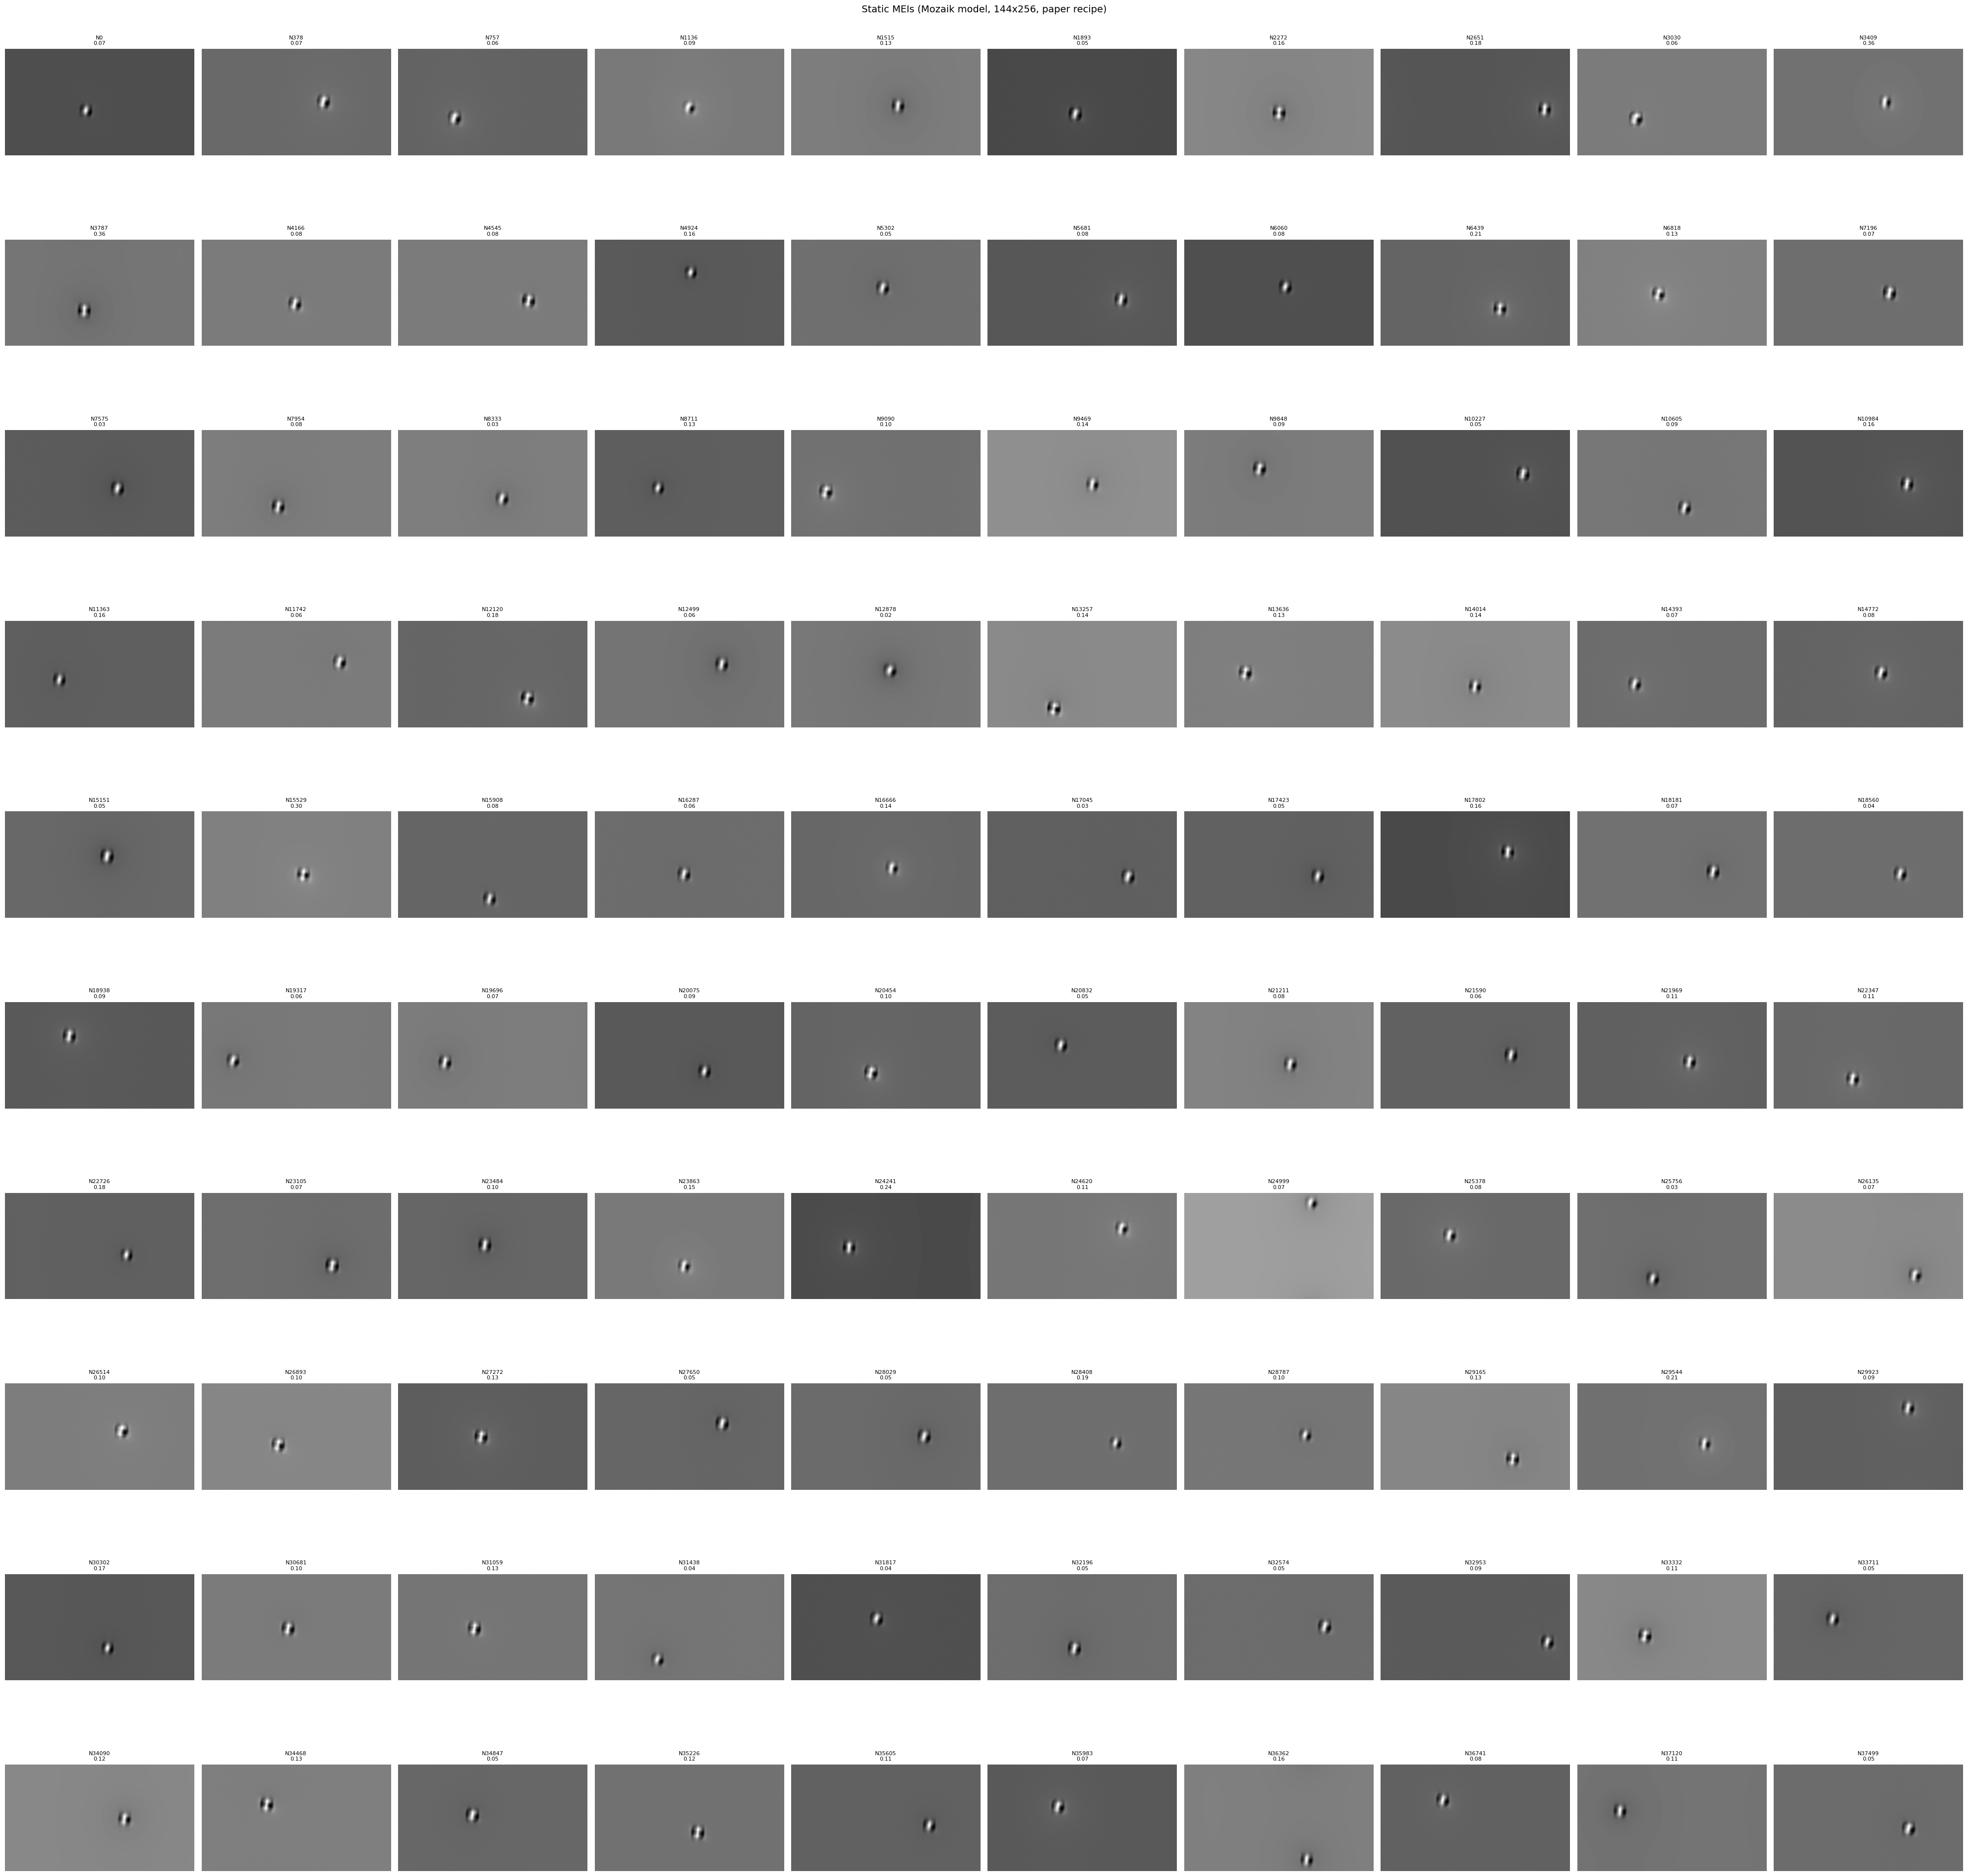

In [13]:
n_show = max(N_DEMO, 16)
ncols = 10
nrows = (n_show + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
for ax, idx in zip(axes.flat, neuron_indices[:n_show]):
    img = static_meis[idx].squeeze().numpy()
    ax.imshow(img, cmap='gray')#, vmin=-1, vmax=1)
    ax.set_title(f'N{idx}\n{static_activations[idx][-1]:.2f}', fontsize=8)
    ax.axis('off')
# Hide unused axes
for ax in axes.flat[n_show:]:
    ax.set_visible(False)
plt.suptitle(f'Static MEIs (Mozaik model, {IMG_H}x{IMG_W}, paper recipe)', fontsize=14)
plt.tight_layout()
fig.savefig('../../figures/mei/static_meis_mozaik_paper.png', dpi=150)
plt.show()

## Run Video MEI generation

Video MEIs at 144x256 are memory-intensive. We generate for a small subset.

In [ ]:
N_VIDEO = 4  # video MEIs are expensive at 144x256; adjust as GPU allows
print(f"Generating video MEIs for {N_VIDEO} neurons")

video_meis = {}
video_activations = {}

for i, idx in enumerate(neuron_indices[:N_VIDEO]):
    vmei, veval, vacts = generate_video_mei(model, data_key, idx, recipe='paper')
    video_meis[idx] = vmei.cpu()
    video_activations[idx] = vacts
    print(f"  [{i+1}/{N_VIDEO}] Neuron {idx}: video={veval:.4f}")

print("Done.")

## Visualize Video MEIs

Frame montage and temporal summary (mean + std across time).

In [ ]:
def plot_video_mei_montage(video_mei, neuron_idx, n_show=8):
    """Show evenly spaced frames from a video MEI."""
    video = video_mei.squeeze().numpy()  # (T, H, W)
    T = video.shape[0]
    frame_ids = np.linspace(0, T - 1, n_show, dtype=int)
    fig, axes = plt.subplots(1, n_show, figsize=(3 * n_show, 4))
    for ax, fi in zip(axes, frame_ids):
        ax.imshow(video[fi], cmap='gray')
        ax.set_title(f't={fi}', fontsize=9)
        ax.axis('off')
    fig.suptitle(f'Video MEI frames - Neuron {neuron_idx}', fontsize=12)
    plt.tight_layout()
    return fig


def plot_video_mei_summary(video_mei, neuron_idx):
    """Show temporal mean and std of a video MEI."""
    video = video_mei.squeeze().numpy()  # (T, H, W)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].imshow(video.mean(axis=0), cmap='gray')
    axes[0].set_title('Temporal Mean')
    axes[1].imshow(video.std(axis=0), cmap='hot')
    axes[1].set_title('Temporal Std (dynamic regions)')
    for ax in axes:
        ax.axis('off')
    fig.suptitle(f'Video MEI Summary - Neuron {neuron_idx}', fontsize=12)
    plt.tight_layout()
    return fig


for idx in list(video_meis.keys()):
    plot_video_mei_montage(video_meis[idx], idx)
    plot_video_mei_summary(video_meis[idx], idx)
plt.show()

## Comparison: Static vs Video MEI + Activation Curves

In [ ]:
# Only compare neurons that have both static and video MEIs
common = [idx for idx in video_meis if idx in static_meis]
if common:
    fig, axes = plt.subplots(2, len(common), figsize=(4 * len(common), 8))
    if len(common) == 1:
        axes = axes[:, None]

    for j, idx in enumerate(common):
        axes[0, j].imshow(static_meis[idx].squeeze().numpy(), cmap='gray')
        axes[0, j].set_title(f'N{idx}\n{static_activations[idx][-1]:.2f}', fontsize=8)
        axes[0, j].axis('off')

        video_mean = video_meis[idx].squeeze().numpy().mean(axis=0)
        axes[1, j].imshow(video_mean, cmap='gray')
        axes[1, j].set_title(f'{video_activations[idx][-1]:.2f}', fontsize=8)
        axes[1, j].axis('off')

    axes[0, 0].set_ylabel('Static MEI', fontsize=10)
    axes[1, 0].set_ylabel('Video MEI\n(temporal mean)', fontsize=10)
    plt.suptitle('Static vs Video MEI comparison (Mozaik model)', fontsize=14)
    plt.tight_layout()
    plt.show()

    # Activation curves
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    for idx in common:
        ax1.plot(static_activations[idx], label=f'N{idx}', alpha=0.7)
    ax1.set_xlabel('Iteration')
    ax1.set_ylabel('Predicted firing rate')
    ax1.set_title('Static MEI optimization')
    ax1.legend(fontsize=7)

    for idx in common:
        ax2.plot(video_activations[idx], label=f'N{idx}', alpha=0.7)
    ax2.set_xlabel('Iteration')
    ax2.set_ylabel('Predicted firing rate')
    ax2.set_title('Video MEI optimization')
    ax2.legend(fontsize=7)
    plt.tight_layout()
    plt.show()
else:
    print("No common neurons between static and video MEIs.")

## Animate a Video MEI

In [ ]:
def animate_video_mei(video_mei, neuron_idx, fps=15):
    """Create inline animation of a video MEI."""
    video = video_mei.squeeze().numpy()  # (T, H, W)
    fig, ax = plt.subplots(figsize=(8, 4.5))
    im = ax.imshow(video[0], cmap='gray', animated=True)
    ax.axis('off')
    title = ax.set_title(f'Neuron {neuron_idx} - frame 0/{len(video)-1}')

    def update(frame):
        im.set_data(video[frame])
        title.set_text(f'Neuron {neuron_idx} - frame {frame}/{len(video)-1}')
        return [im, title]

    anim = animation.FuncAnimation(fig, update, frames=len(video),
                                   interval=1000 // fps, blit=True)
    plt.close(fig)
    return anim


if video_meis:
    first_idx = list(video_meis.keys())[0]
    anim = animate_video_mei(video_meis[first_idx], first_idx)
    HTML(anim.to_jshtml())